In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("/content/PCOS_data.csv")
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0,0,120,80,3,4,16.0,14.0,7.0


In [ ]:
#EDA

In [ ]:
df.shape

(541, 44)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
df.isnull().sum()

Sl. No                    0
Patient File No.          0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     1
Pregnant(Y/N)             0
No. of abortions          0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)     

In [ ]:
df.dropna()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.000,19.3,15,78,22,...,0,1,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.500,24.9,15,74,20,...,0,0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.000,25.3,11,72,18,...,1,1,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.000,29.7,13,72,20,...,0,0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.000,20.1,11,72,18,...,0,0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537,537,0,35,50.0,164.592,18.5,17,72,16,...,0,0,0,110,70,1,0,17.5,10.0,6.7
537,538,538,0,30,63.2,158.000,25.3,15,72,18,...,0,0,0,110,70,9,7,19.0,18.0,8.2
538,539,539,0,36,54.0,152.000,23.4,13,74,20,...,0,0,0,110,80,1,0,18.0,9.0,7.3
539,540,540,0,27,50.0,150.000,22.2,15,74,20,...,1,0,0,110,70,7,6,18.0,16.0,11.5


In [ ]:
#convert to numerical data
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'],errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'],errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
df.columns

Index(['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)',
       'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions',
       '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

In [ ]:
df.corr()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
Sl. No,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.082840,0.001705,-0.044533,-0.015196,...,0.160834,0.155298,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
Patient File No.,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,-0.082840,0.001705,-0.044533,-0.015196,...,0.160834,0.155298,0.000110,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219
PCOS (Y/N),0.060998,0.060998,1.000000,-0.168513,0.211938,0.068254,0.199697,0.036433,0.091821,0.036928,...,0.286077,0.378720,0.065337,0.007942,0.038032,0.603346,0.648327,0.132992,0.097690,0.106648
Age (yrs),0.067133,0.067133,-0.168513,1.000000,-0.029734,-0.119819,0.021372,-0.010954,0.045831,0.087382,...,-0.032921,-0.036073,-0.025911,0.073587,0.066788,-0.110793,-0.159395,-0.016352,-0.079250,-0.104238
Weight (Kg),-0.082823,-0.082823,0.211938,-0.029734,1.000000,0.420098,0.901688,0.072682,0.019983,0.043614,...,0.063983,0.162917,-0.068236,0.027608,0.131402,0.173751,0.124290,-0.021368,-0.073207,-0.010100
Height(Cm),-0.011700,-0.011700,0.068254,-0.119819,0.420098,1.000000,-0.006845,0.040825,-0.074339,-0.029459,...,0.061129,0.031905,0.012943,-0.067959,0.011116,0.106189,0.075358,-0.026705,0.059426,-0.054035
BMI,-0.082840,-0.082840,0.199697,0.021372,0.901688,-0.006845,1.000000,0.061328,0.050507,0.061579,...,0.045535,0.160472,-0.080660,0.069737,0.140062,0.143110,0.104425,-0.011736,-0.111427,0.009327
Blood Group,0.001705,0.001705,0.036433,-0.010954,0.072682,0.040825,0.061328,1.000000,0.047572,-0.023766,...,0.039029,-0.034219,0.064035,0.030898,0.054014,0.061332,0.013974,-0.035667,-0.015725,-0.015335
Pulse rate(bpm),-0.044533,-0.044533,0.091821,0.045831,0.019983,-0.074339,0.050507,0.047572,1.000000,0.303804,...,-0.003039,0.060278,-0.038881,-0.025510,0.007623,0.040390,0.049182,-0.048356,-0.034202,-0.041241
RR (breaths/min),-0.015196,-0.015196,0.036928,0.087382,0.043614,-0.029459,0.061579,-0.023766,0.303804,1.000000,...,0.029242,0.131901,-0.047451,0.017323,0.052631,0.069731,0.012441,-0.031051,-0.021893,-0.063930


In [ ]:
correlation_with_target = df.corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(correlation_with_target)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.378720
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.263863
Weight (Kg)               0.211938
BMI                       0.199697
Cycle length(days)        0.178480
Hair loss(Y/N)            0.172879
 Age (yrs)                0.168513
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Marraige Status (Yrs)     0.112897
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
Sl. No                    0.060998
Patient File No.    

In [ ]:
#plots

In [ ]:
#Distribution of PCOS Cases Across Age Groups

In [ ]:
e# Define age group bins and labels
age_groups = [0,18,25,35,45,float('inf')]
age_labels = ['<18','18-25','26-35','36-45','45+']
df['Age Group'] = pd.cut(df[' Age (yrs)'],bins = age_groups,labels = age_labels)

In [ ]:
# Categorize the 'Age (yrs)' column into age groups
age_group_counts = df.groupby(['Age Group', 'PCOS (Y/N)']).size().unstack()
type(age_group_counts)

pandas.core.frame.DataFrame

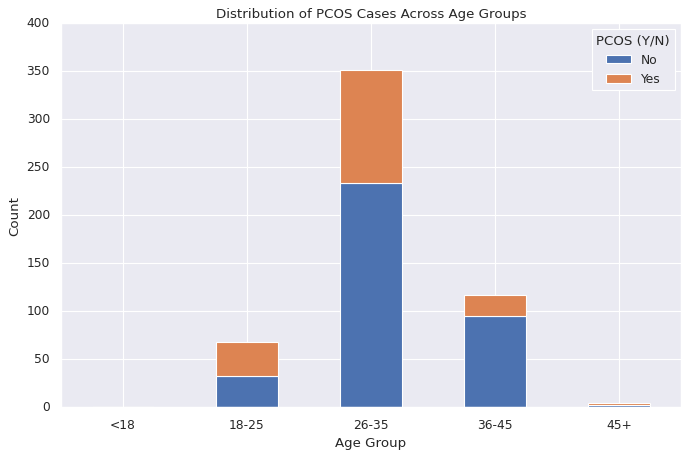

In [ ]:
age_group_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribution of PCOS Cases Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='PCOS (Y/N)', loc='upper right', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

In [ ]:
#PCOS affects mainly the age group of 26-35 and 18-15.

In [ ]:
#Distribution analysis for numerical attributes

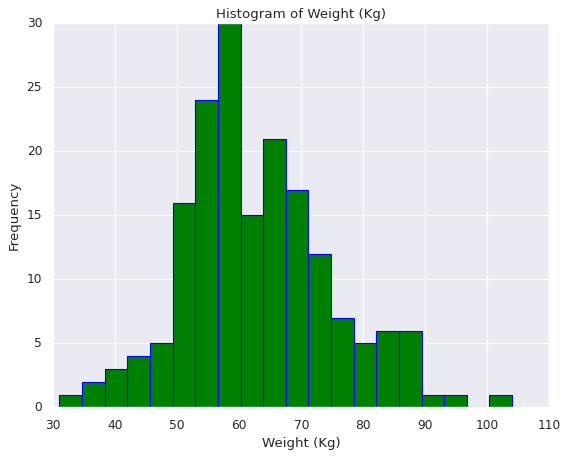

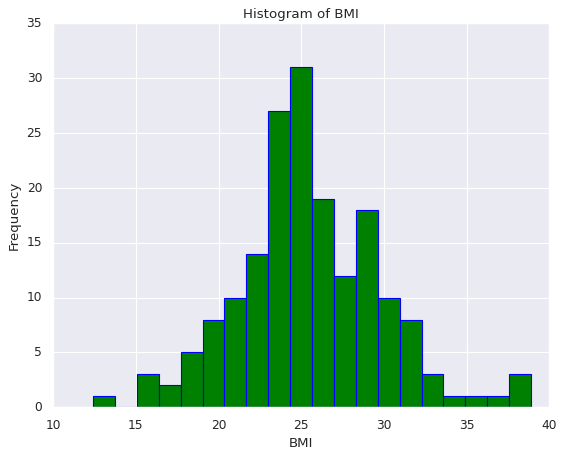

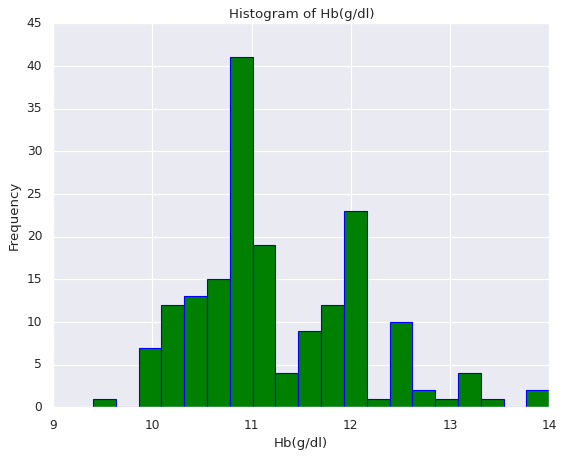

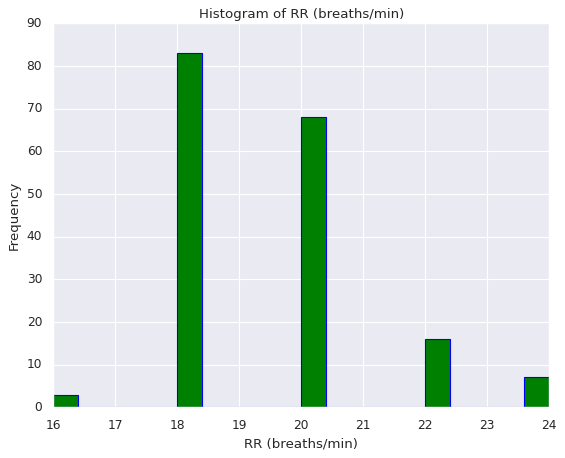

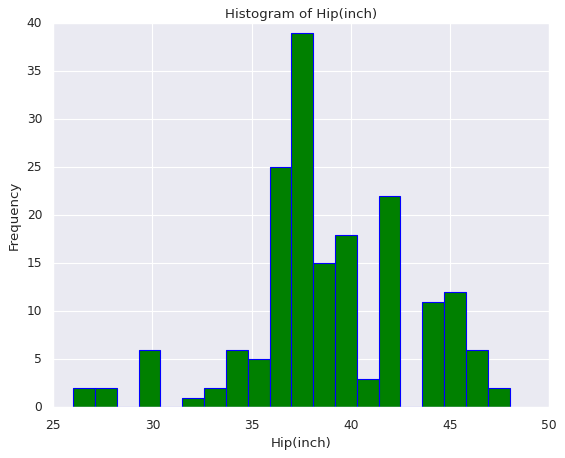

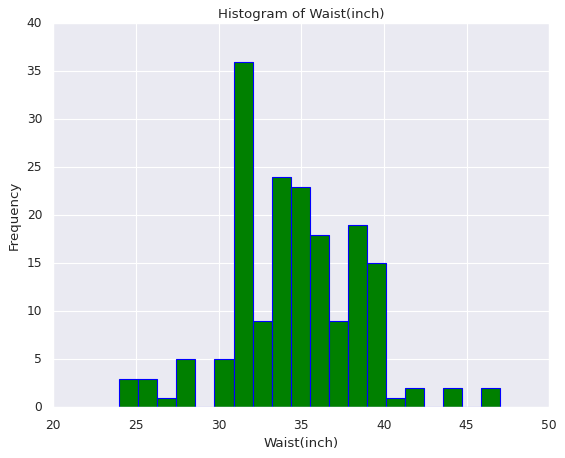

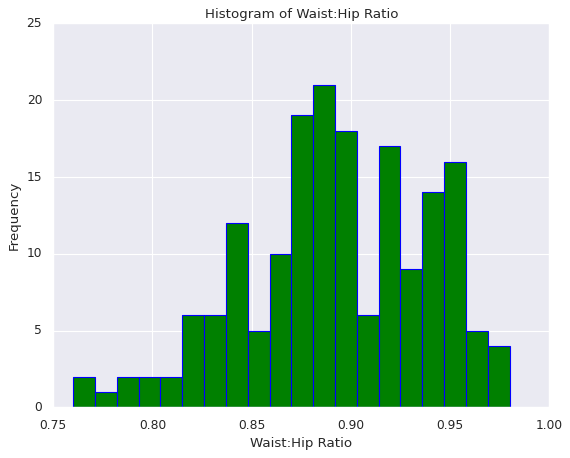

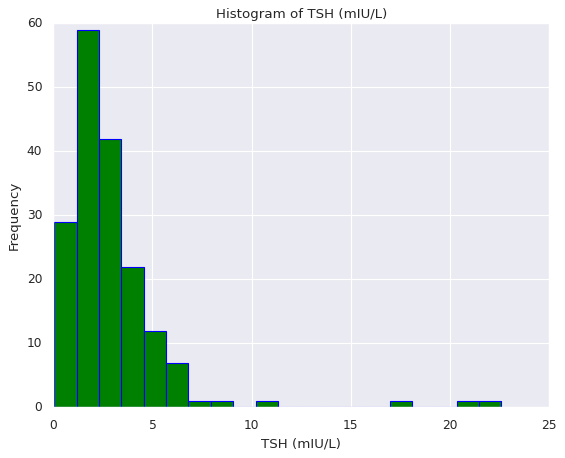

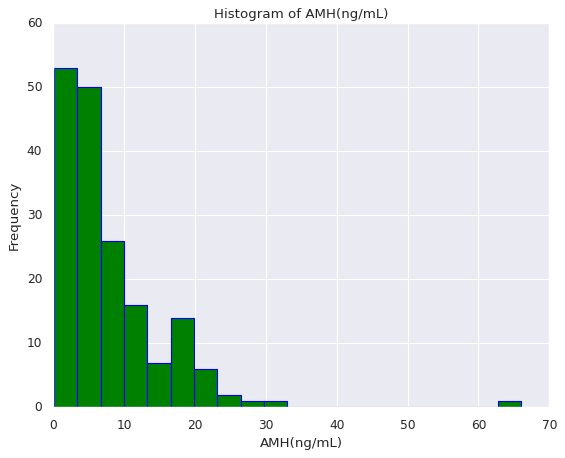

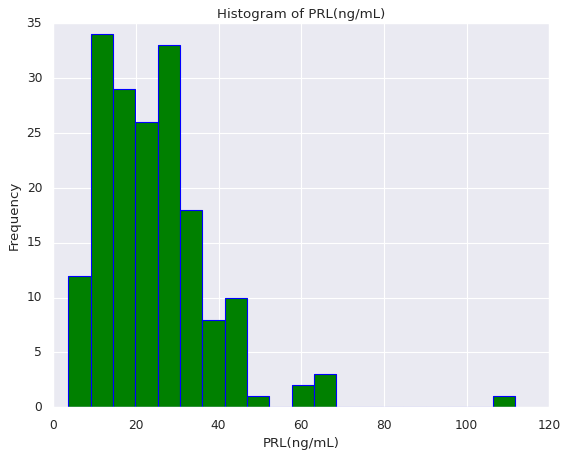

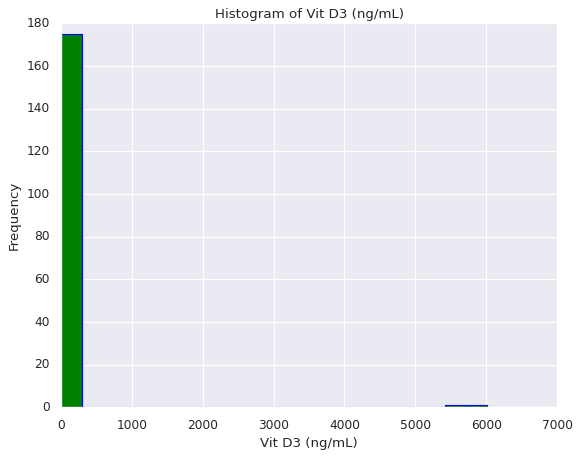

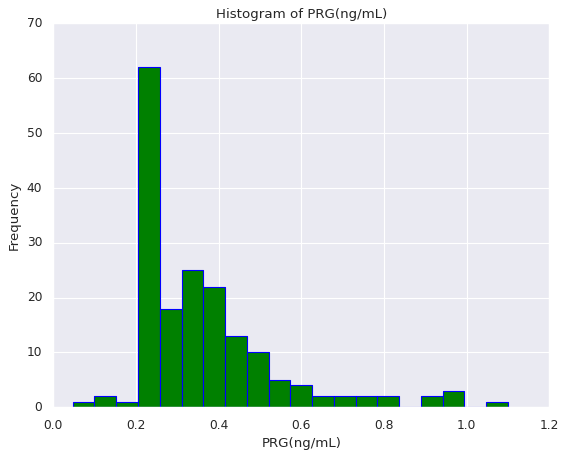

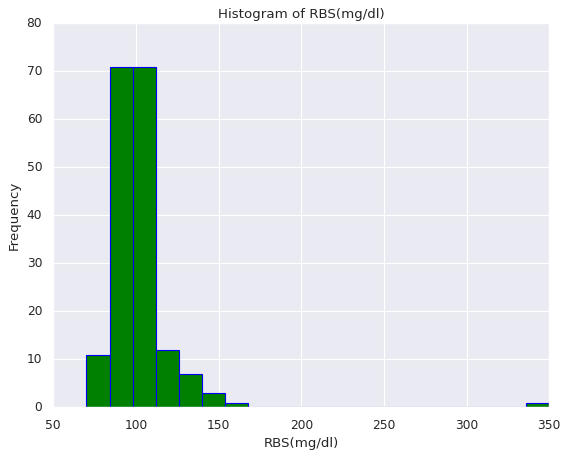

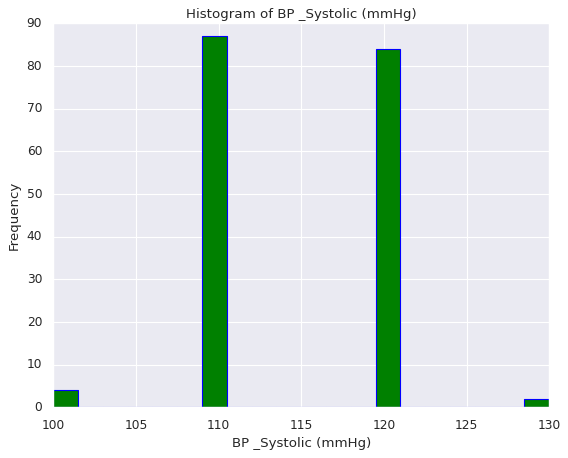

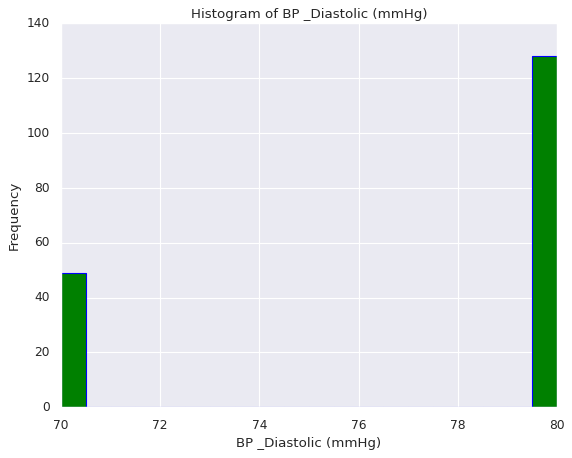

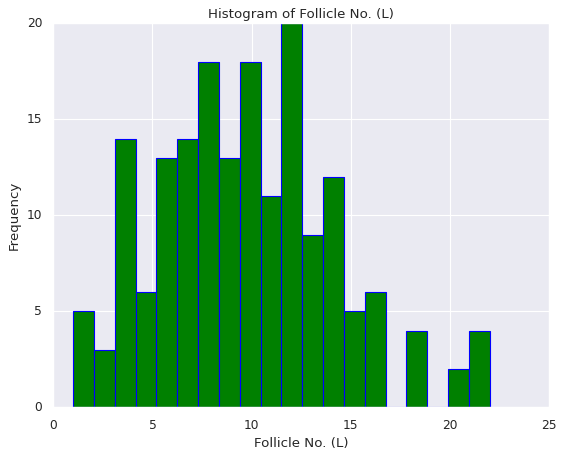

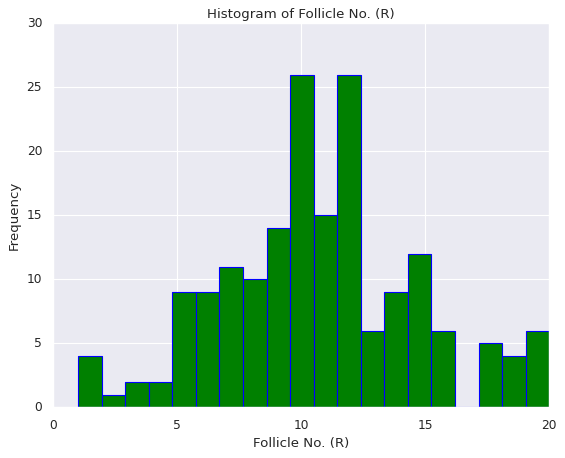

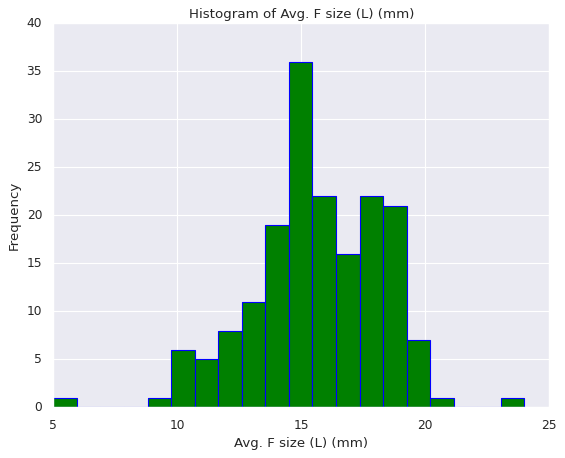

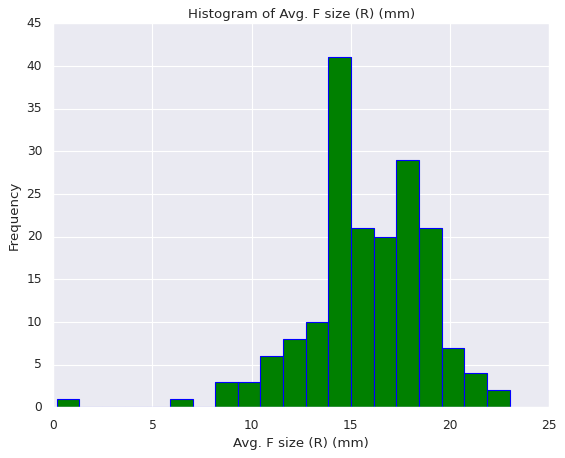

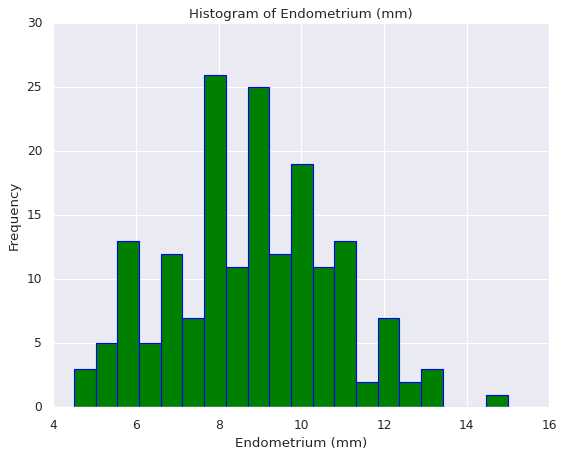

In [ ]:
# List of numerical attributes for distribution analysis
numerical_attributes = ['Weight (Kg)', 'BMI', 'Hb(g/dl)','RR (breaths/min)',
                        'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
                        'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
                        'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
                        'Endometrium (mm)']
df_pcos = df[df['PCOS (Y/N)']==1]
# Create histograms for each numerical attribute
for attribute in numerical_attributes:
    plt.figure(figsize=(8, 6))
    plt.hist(df_pcos[attribute], bins=20, color='green', edgecolor='blue')
    plt.title(f'Histogram of {attribute}')
    plt.xlabel(attribute)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

In [ ]:
#Feature Selection

In [ ]:
top_10_features = correlation_with_target[0:11]
print(top_10_features)

PCOS (Y/N)              1.000000
Follicle No. (R)        0.648327
Follicle No. (L)        0.603346
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401644
Fast food (Y/N)         0.378720
Pimples(Y/N)            0.286077
AMH(ng/mL)              0.263863
Weight (Kg)             0.211938
Name: PCOS (Y/N), dtype: float64


In [ ]:
df_new = df[['PCOS (Y/N)','Follicle No. (R)','Follicle No. (L)','Skin darkening (Y/N)','hair growth(Y/N)','Weight gain(Y/N)','Cycle(R/I)','Fast food (Y/N)','Pimples(Y/N)','AMH(ng/mL)','Weight (Kg)']]

In [ ]:
df_new.isnull().sum()

PCOS (Y/N)              0
Follicle No. (R)        0
Follicle No. (L)        0
Skin darkening (Y/N)    0
hair growth(Y/N)        0
Weight gain(Y/N)        0
Cycle(R/I)              0
Fast food (Y/N)         0
Pimples(Y/N)            0
AMH(ng/mL)              1
Weight (Kg)             0
dtype: int64

In [ ]:
df_new.duplicated().sum()

0

In [ ]:
df_new.isna().sum()

PCOS (Y/N)              0
Follicle No. (R)        0
Follicle No. (L)        0
Skin darkening (Y/N)    0
hair growth(Y/N)        0
Weight gain(Y/N)        0
Cycle(R/I)              0
Fast food (Y/N)         0
Pimples(Y/N)            0
AMH(ng/mL)              1
Weight (Kg)             0
dtype: int64

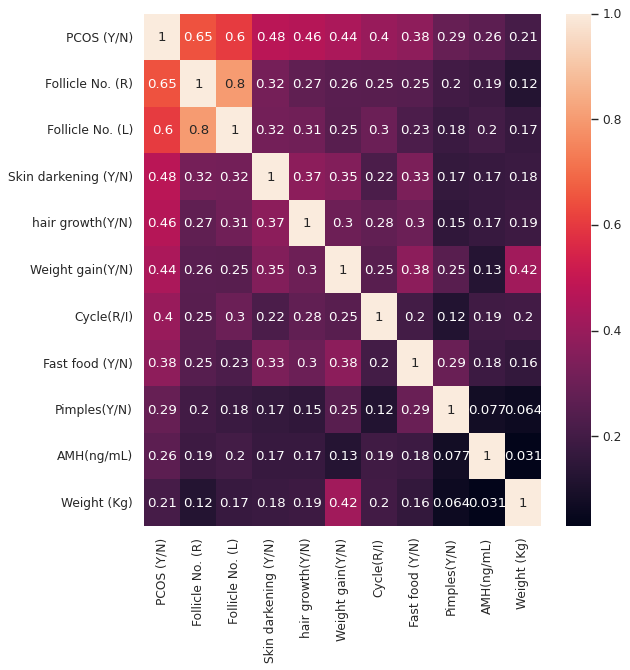

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df_new.corr(),annot=True)
plt.show()

In [ ]:
df_new['PCOS (Y/N)'].value_counts()

0    364
1    177
Name: PCOS (Y/N), dtype: int64

In [ ]:
df_new.dropna(inplace=True)

<ipython-input-198-f6b64f3e8698>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.dropna(inplace=True)


In [ ]:
df_new.isnull().sum()

PCOS (Y/N)              0
Follicle No. (R)        0
Follicle No. (L)        0
Skin darkening (Y/N)    0
hair growth(Y/N)        0
Weight gain(Y/N)        0
Cycle(R/I)              0
Fast food (Y/N)         0
Pimples(Y/N)            0
AMH(ng/mL)              0
Weight (Kg)             0
dtype: int64

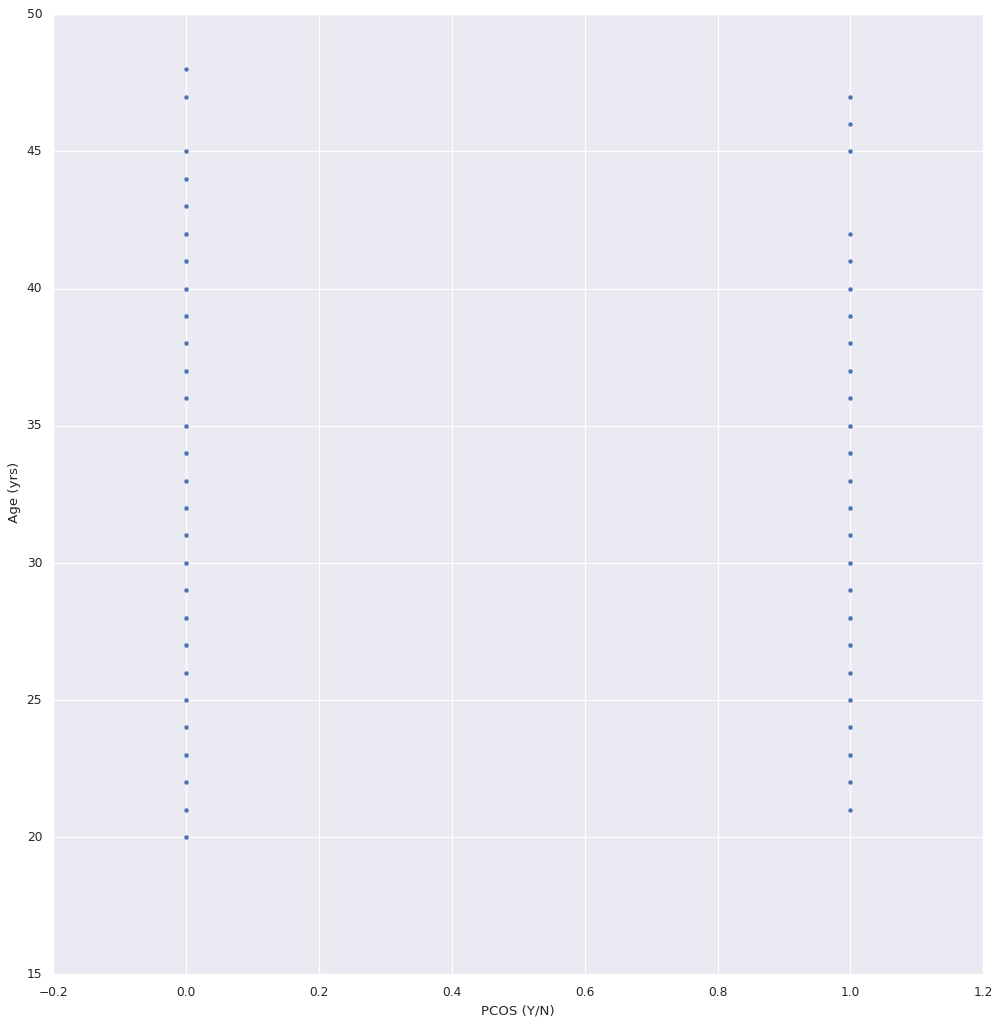

In [ ]:
sns.scatterplot(x='PCOS (Y/N)', y=' Age (yrs)', data=df)
plt.show()
plt.close()


Text(0.5, 0, 'PCOS (Y/N)')

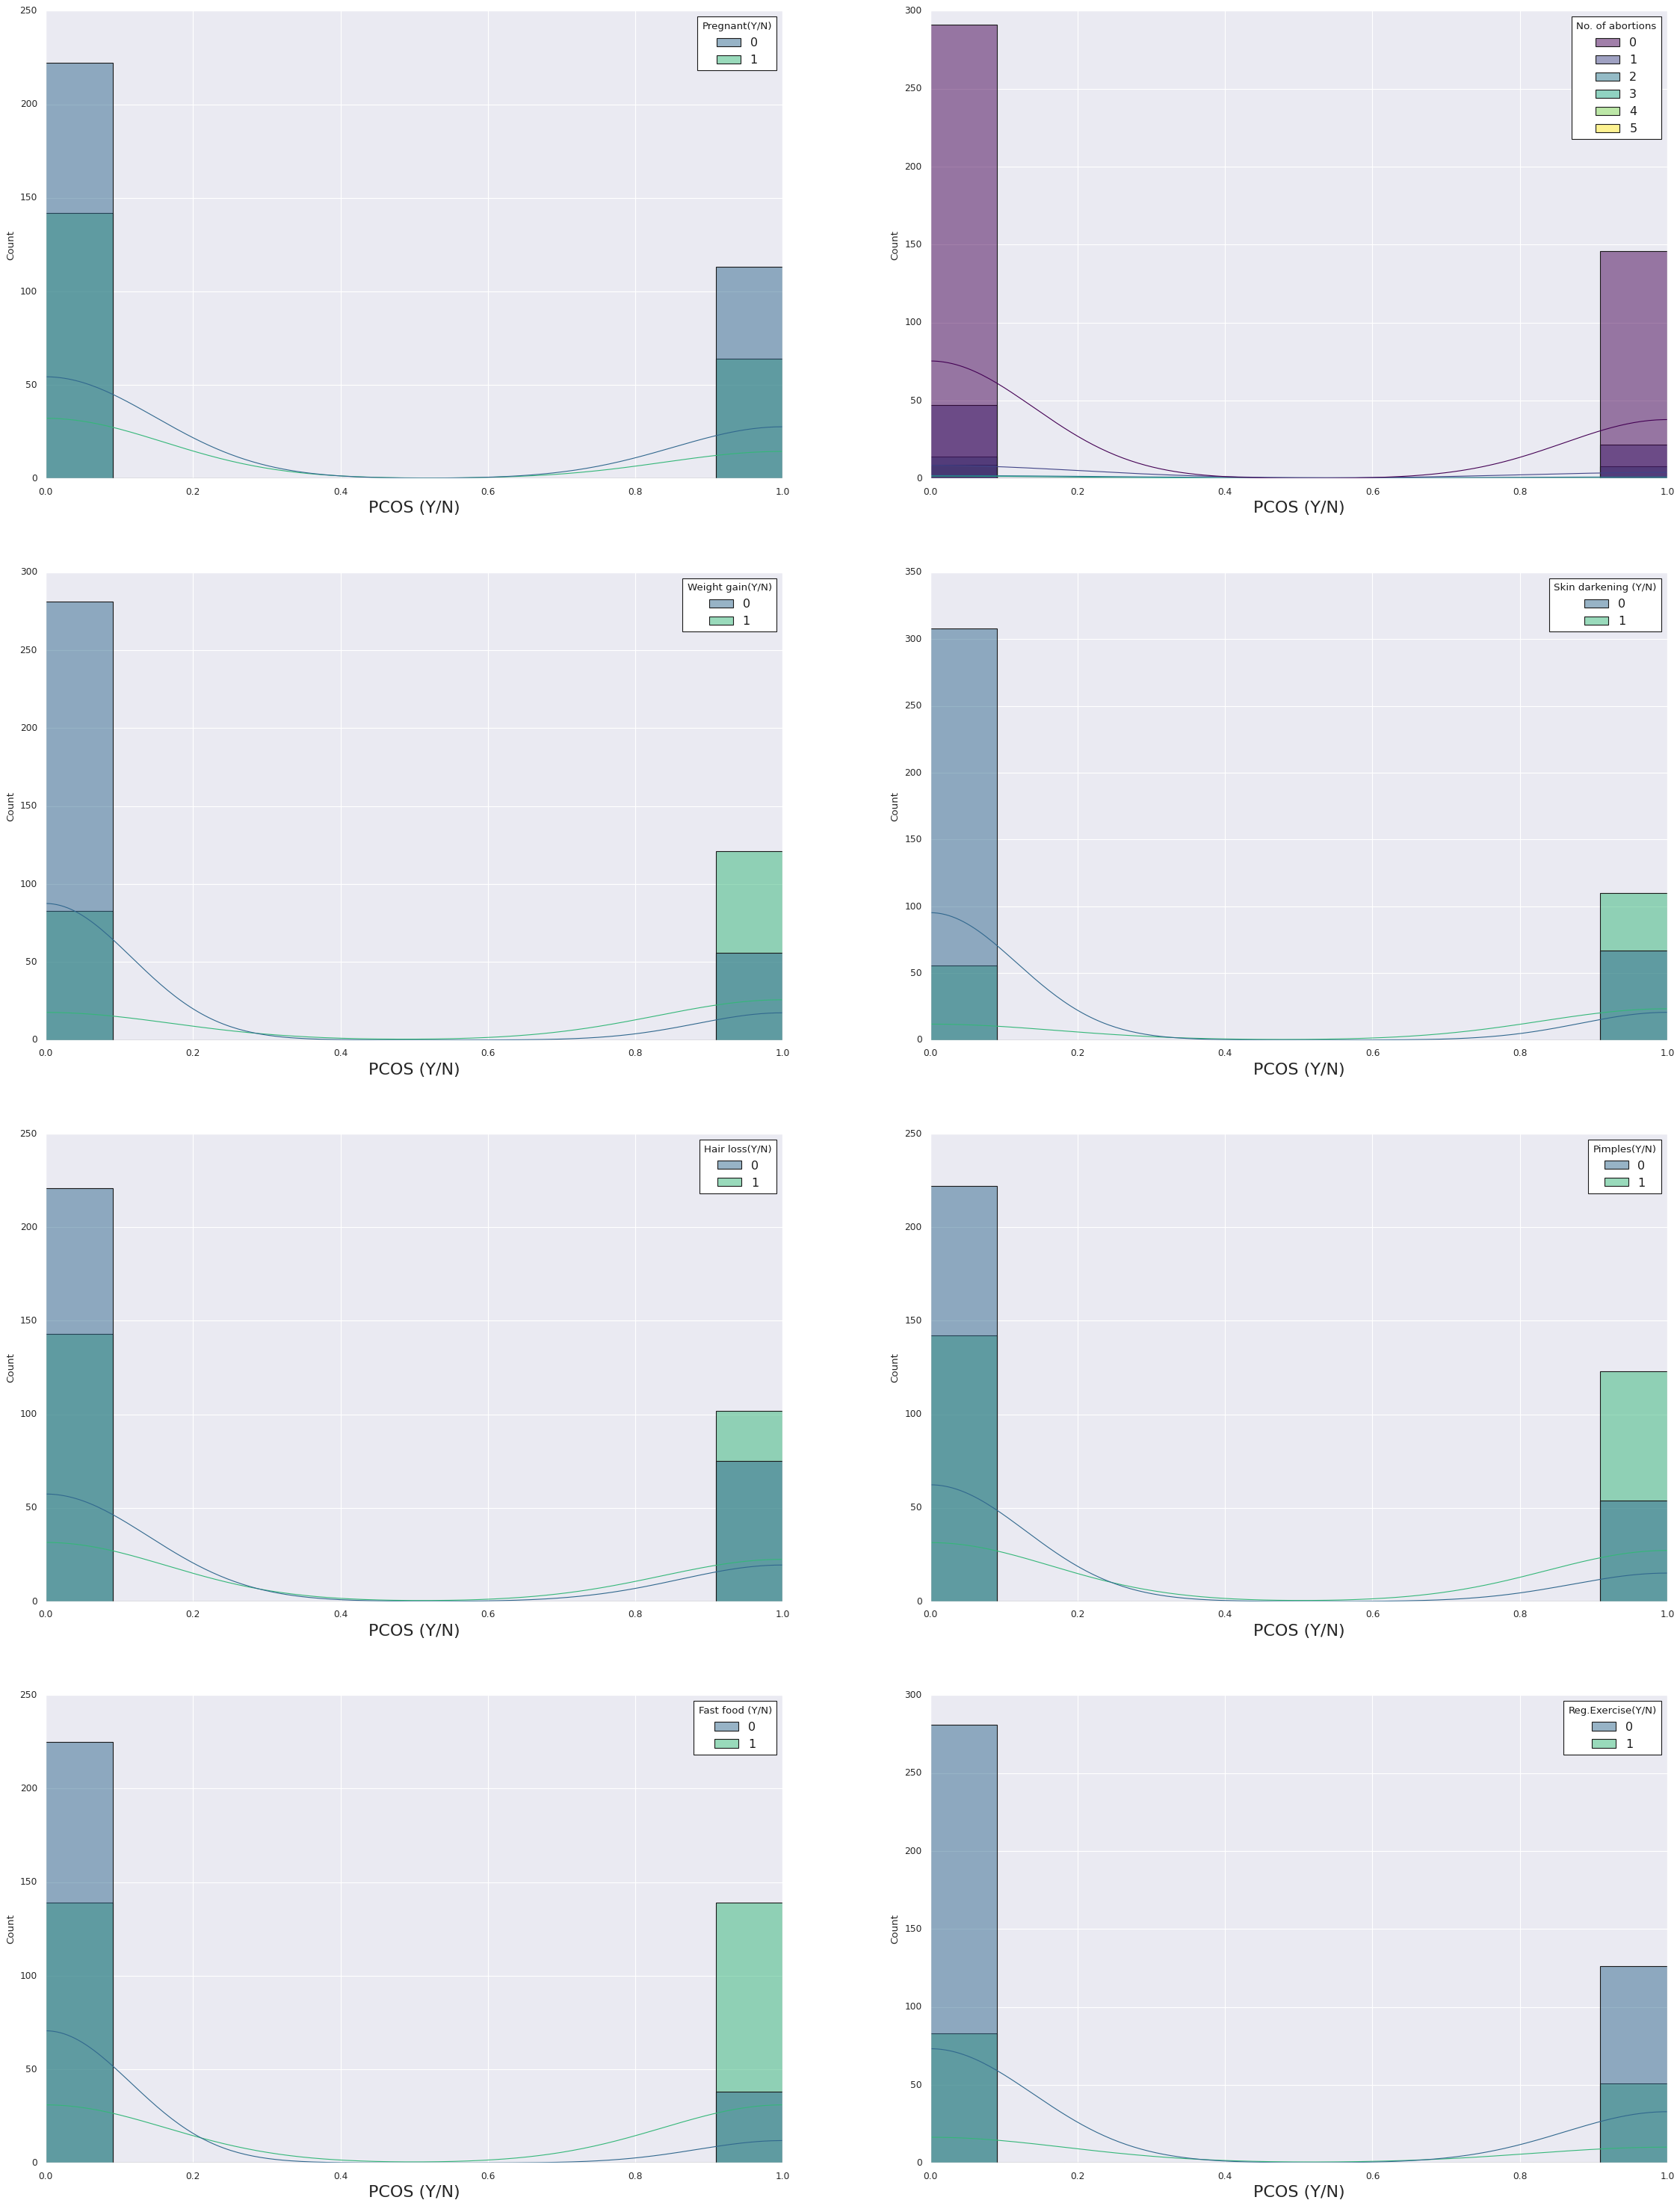

In [ ]:
fig, ax = plt.subplots(4,2, figsize=(35,45))
plt.style.use("classic")

sns.histplot(x = df['PCOS (Y/N)'], hue = df['Pregnant(Y/N)'], palette="viridis", kde=True, ax=ax[0,0])
ax[0,0].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['No. of abortions'], palette="viridis", kde=True, ax=ax[0,1])
ax[0,1].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Weight gain(Y/N)'], palette="viridis", kde=True, ax=ax[1,0])
ax[1,0].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Skin darkening (Y/N)'], palette="viridis", kde=True, ax=ax[1,1])
ax[1,1].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Hair loss(Y/N)'], palette="viridis", kde=True, ax=ax[2,0])
ax[2,0].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Pimples(Y/N)'], palette="viridis", kde=True, ax=ax[2,1])
ax[2,1].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Fast food (Y/N)'], palette="viridis", kde=True, ax=ax[3,0])
ax[3,0].set_xlabel('PCOS (Y/N)',fontsize=20)
sns.histplot(x = df['PCOS (Y/N)'], hue = df['Reg.Exercise(Y/N)'], palette="viridis", kde=True, ax=ax[3,1])
ax[3,1].set_xlabel('PCOS (Y/N)',fontsize=20)

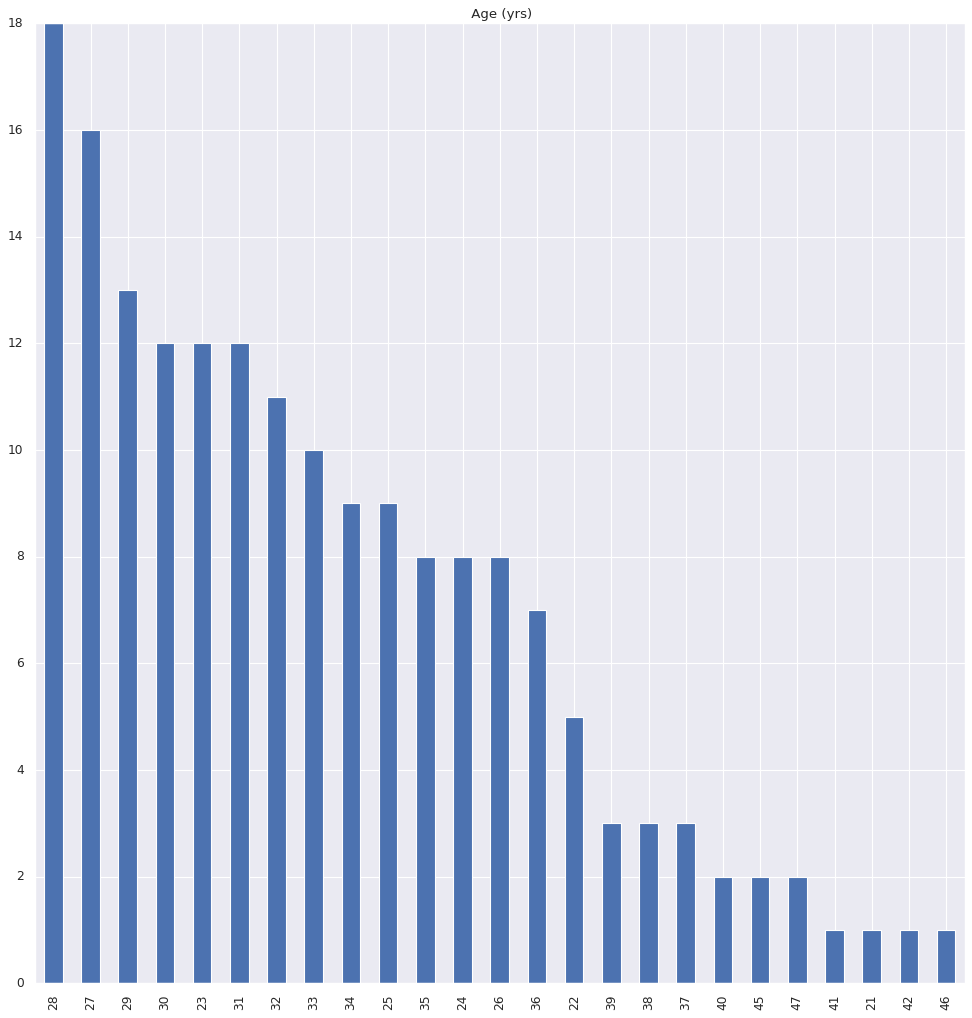

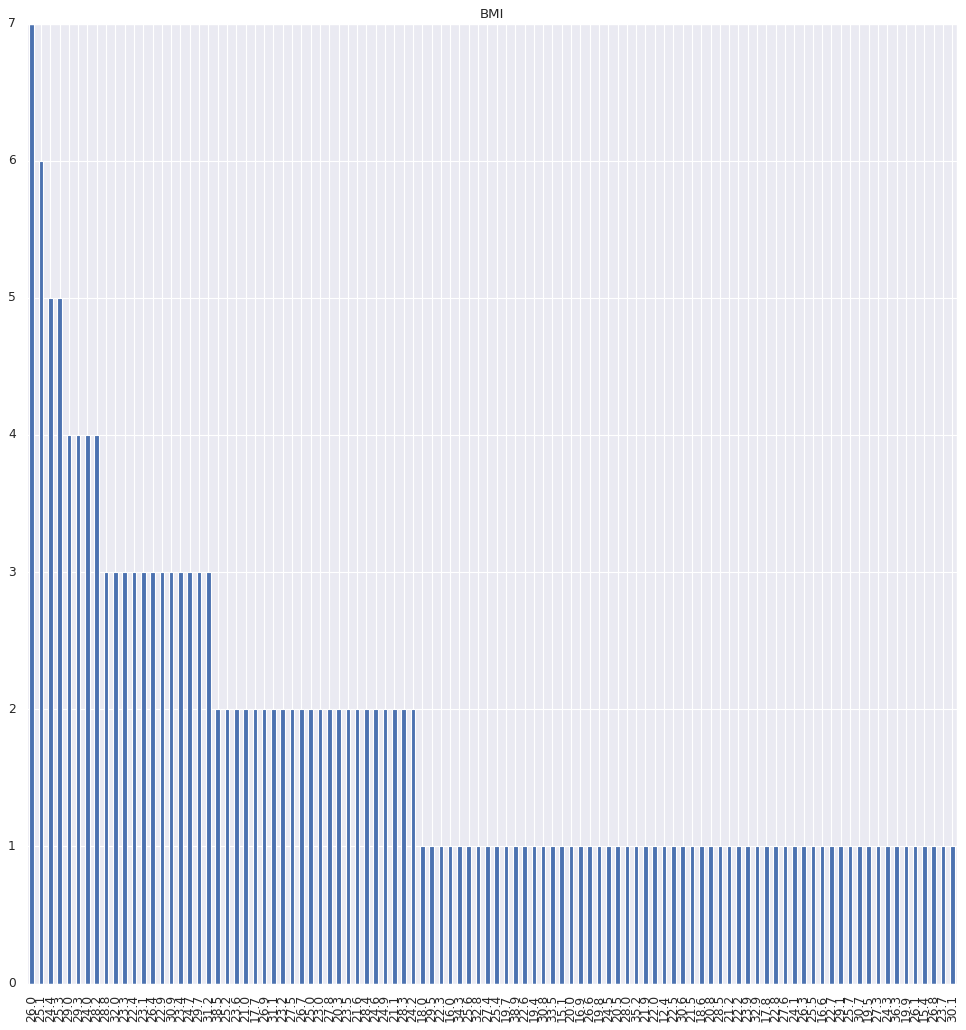

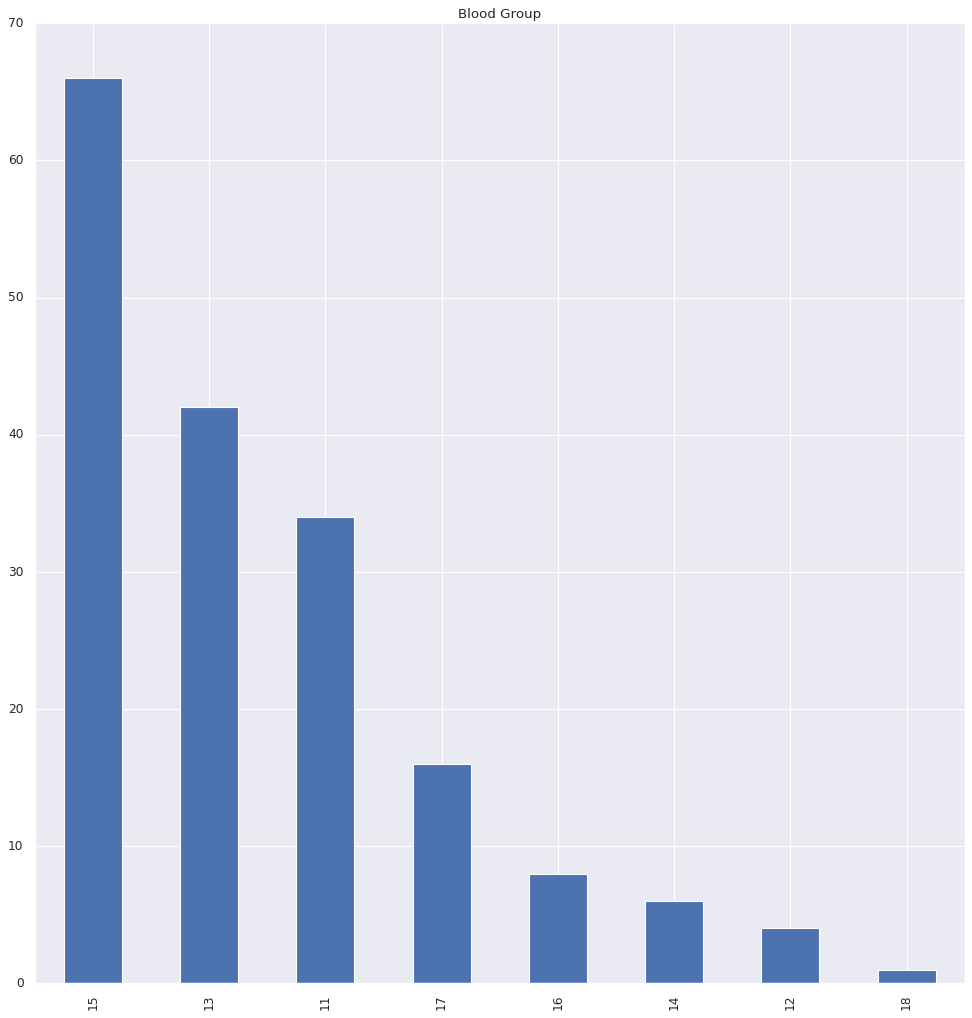

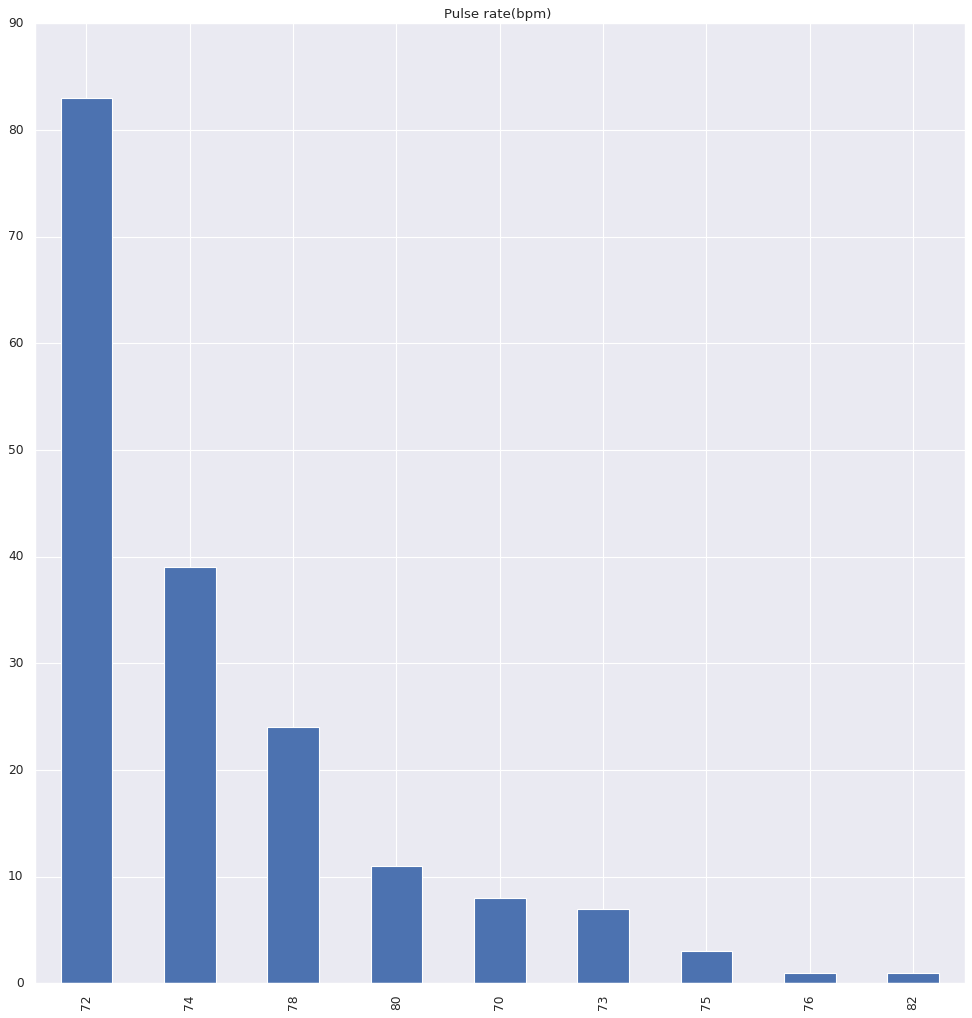

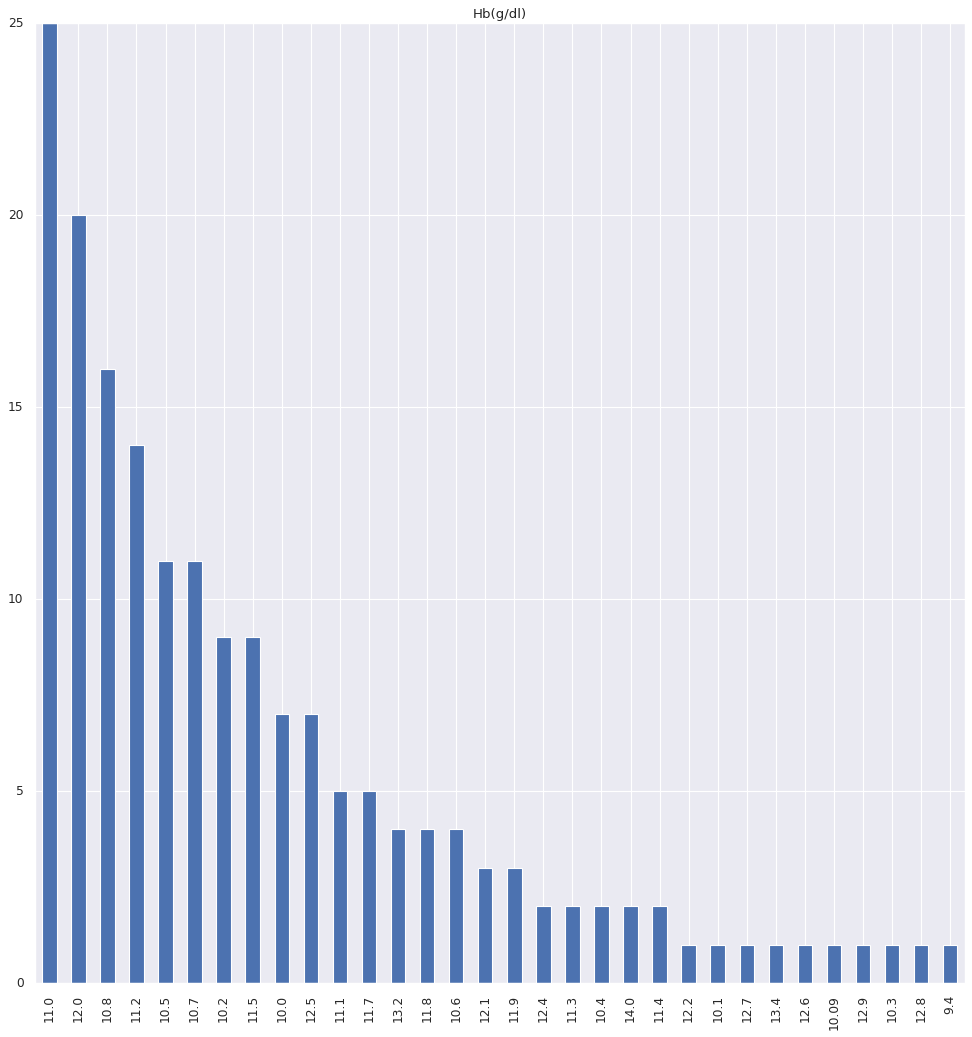

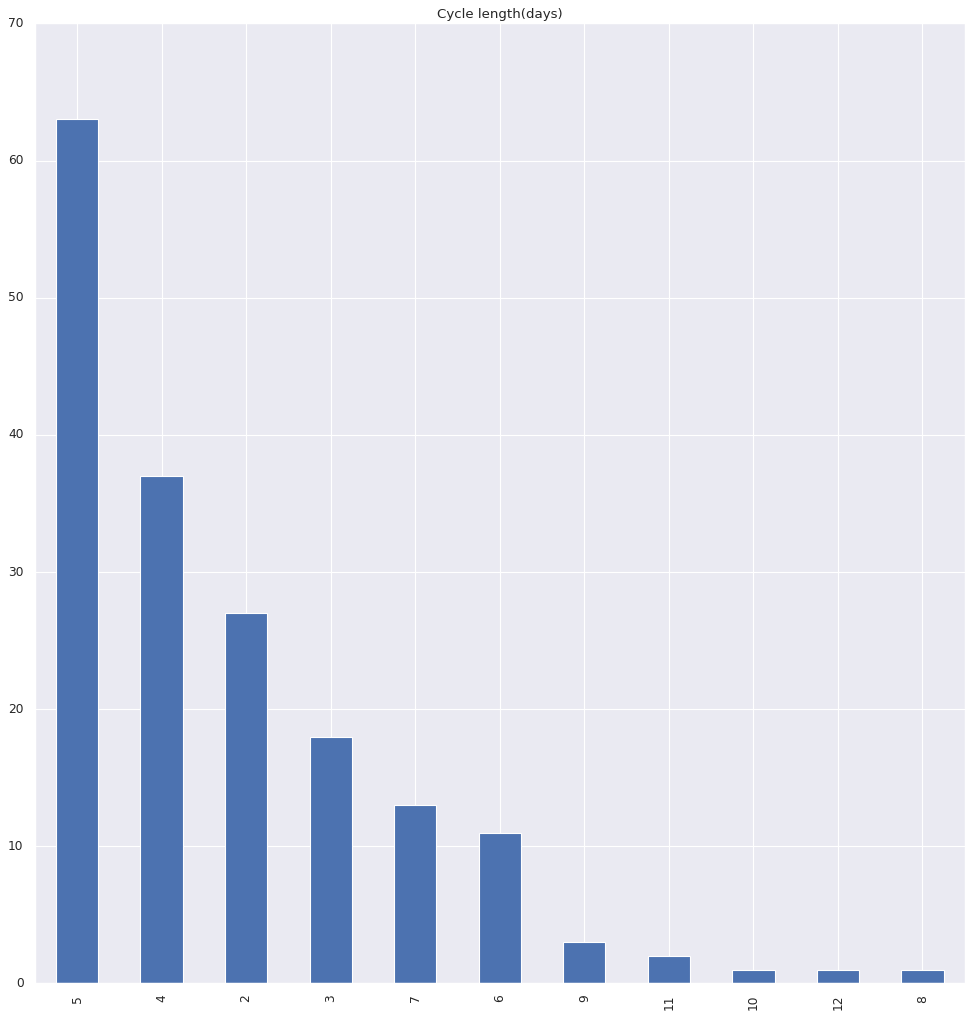

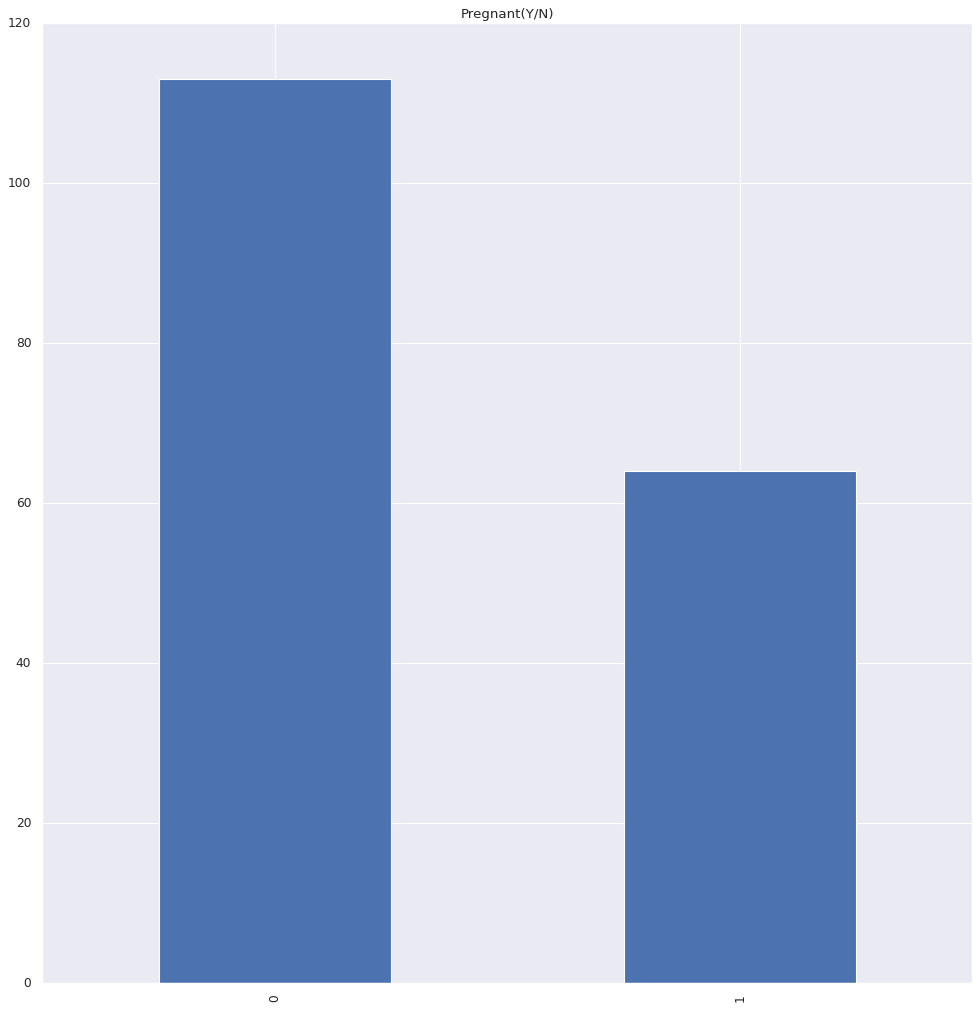

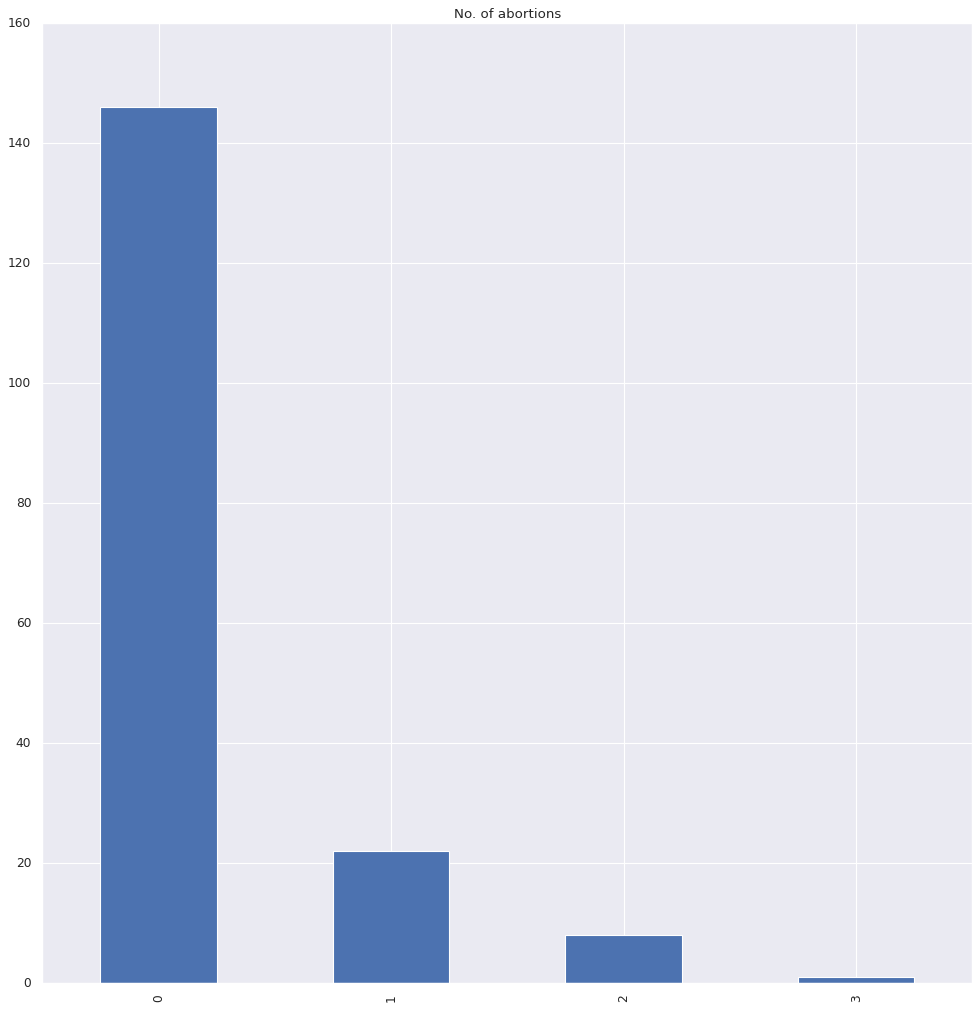

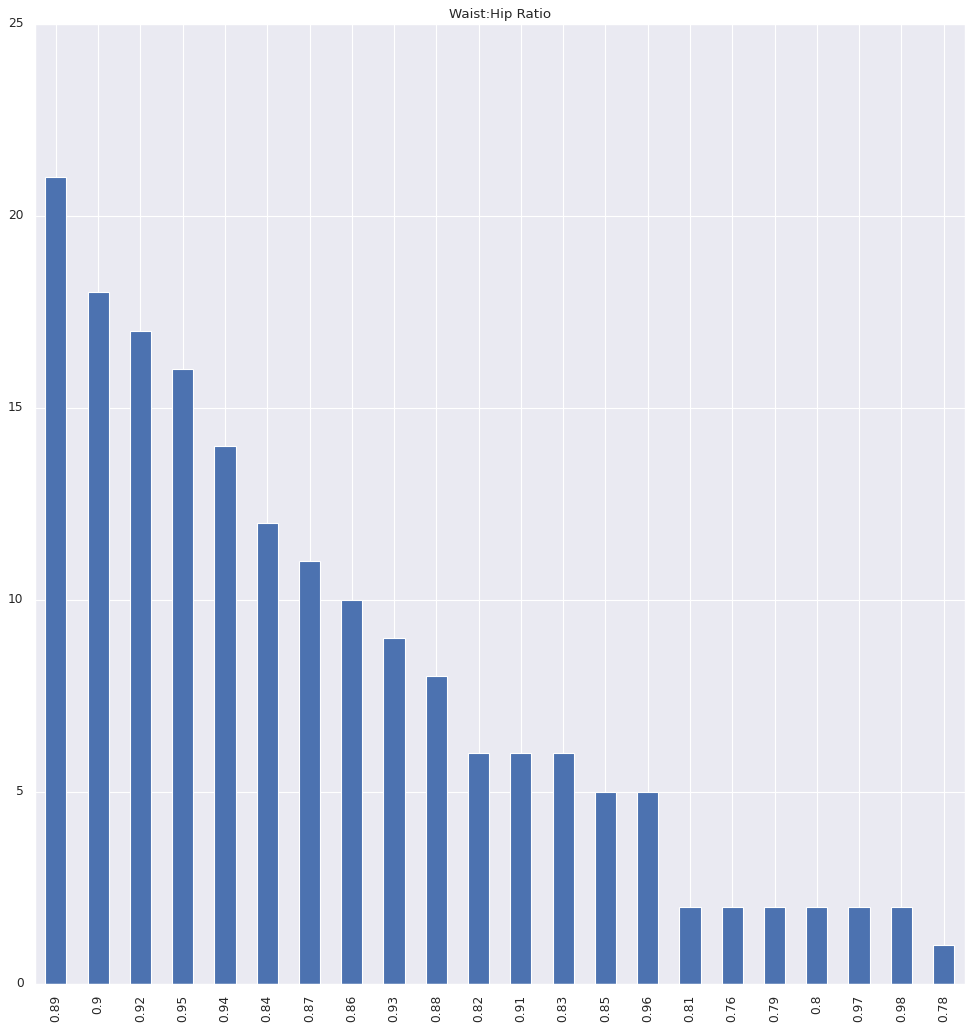

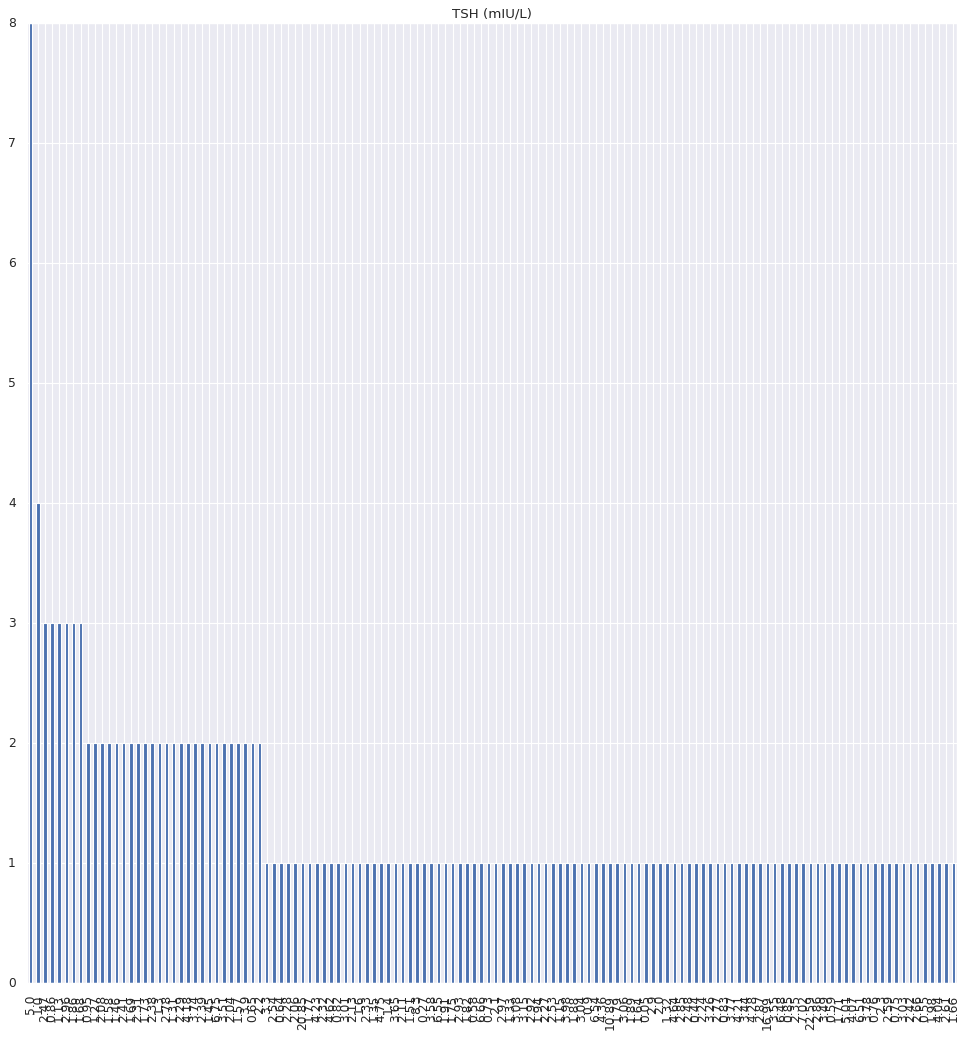

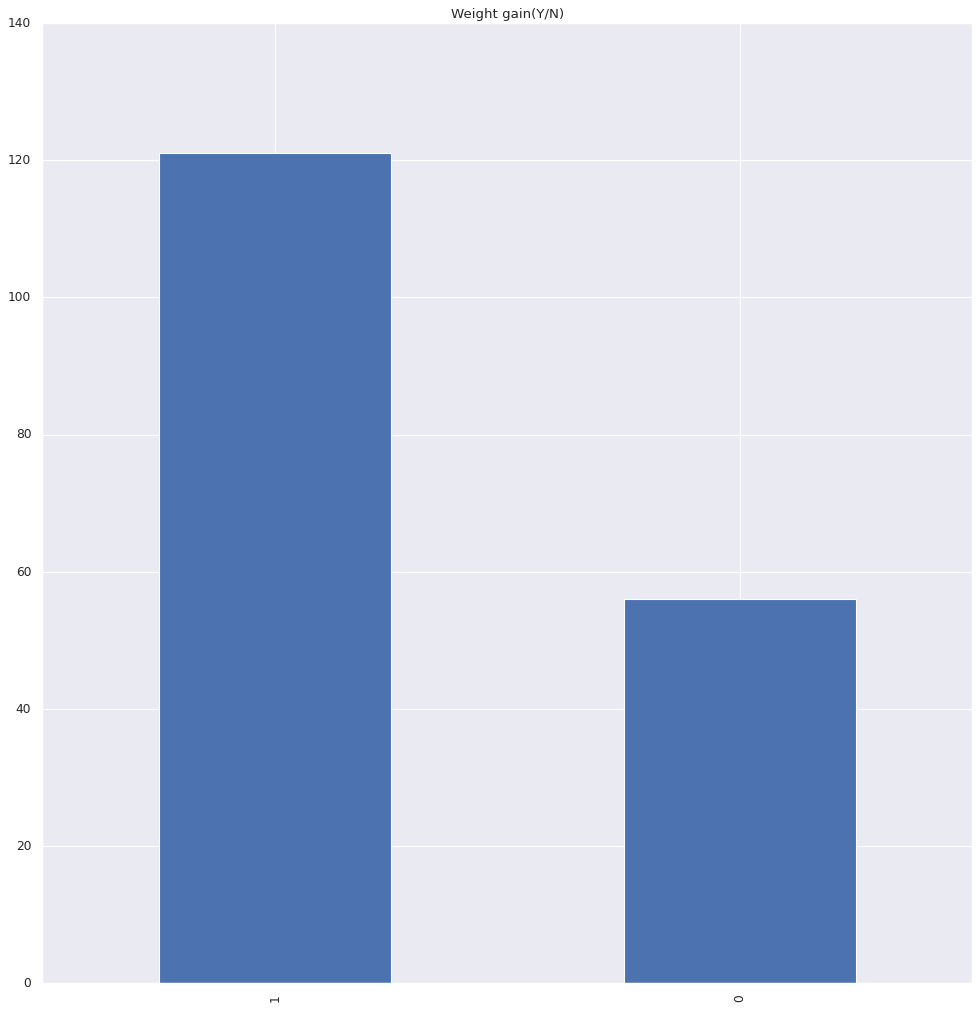

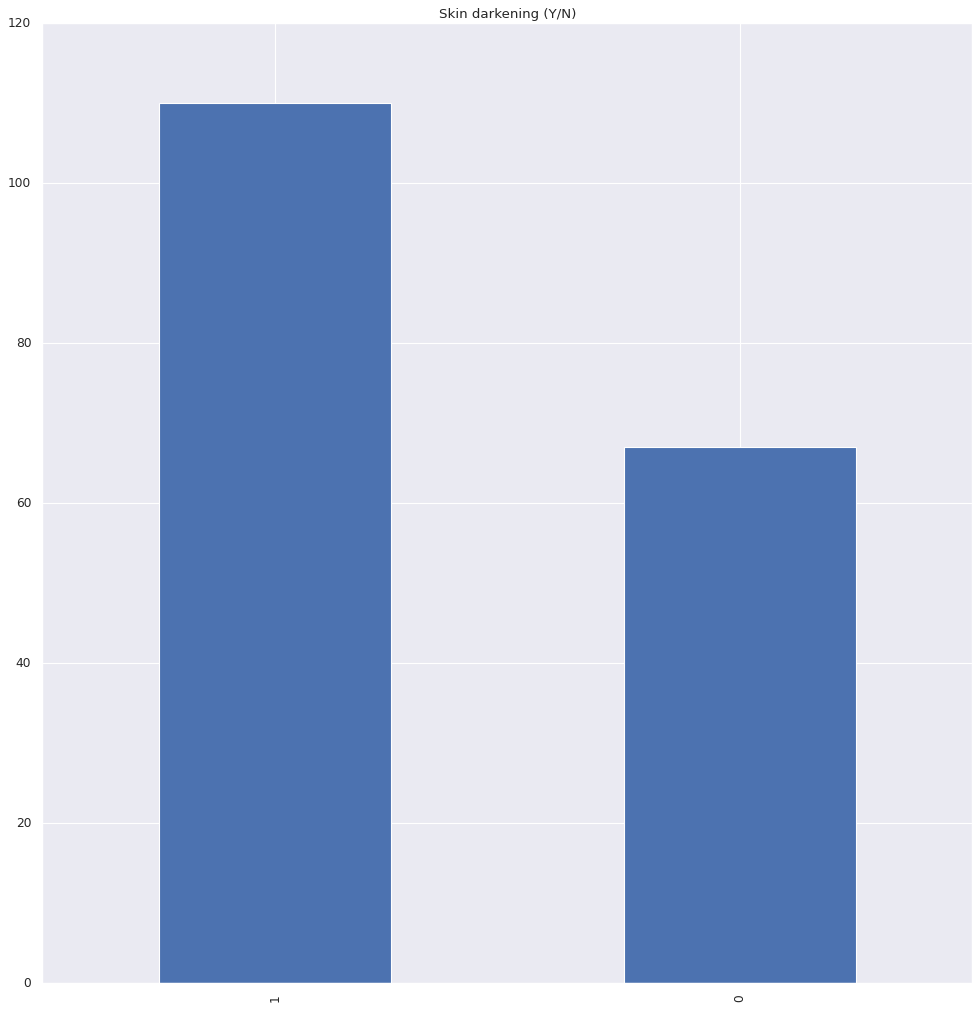

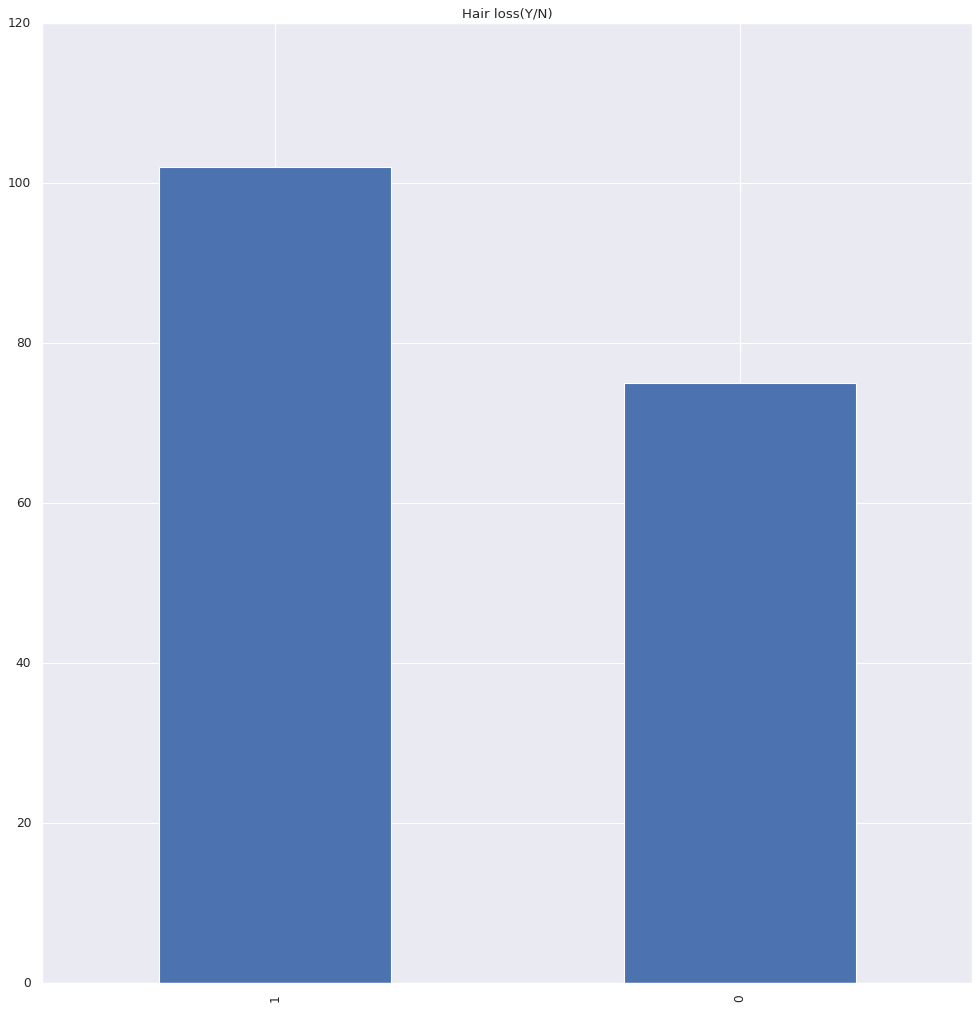

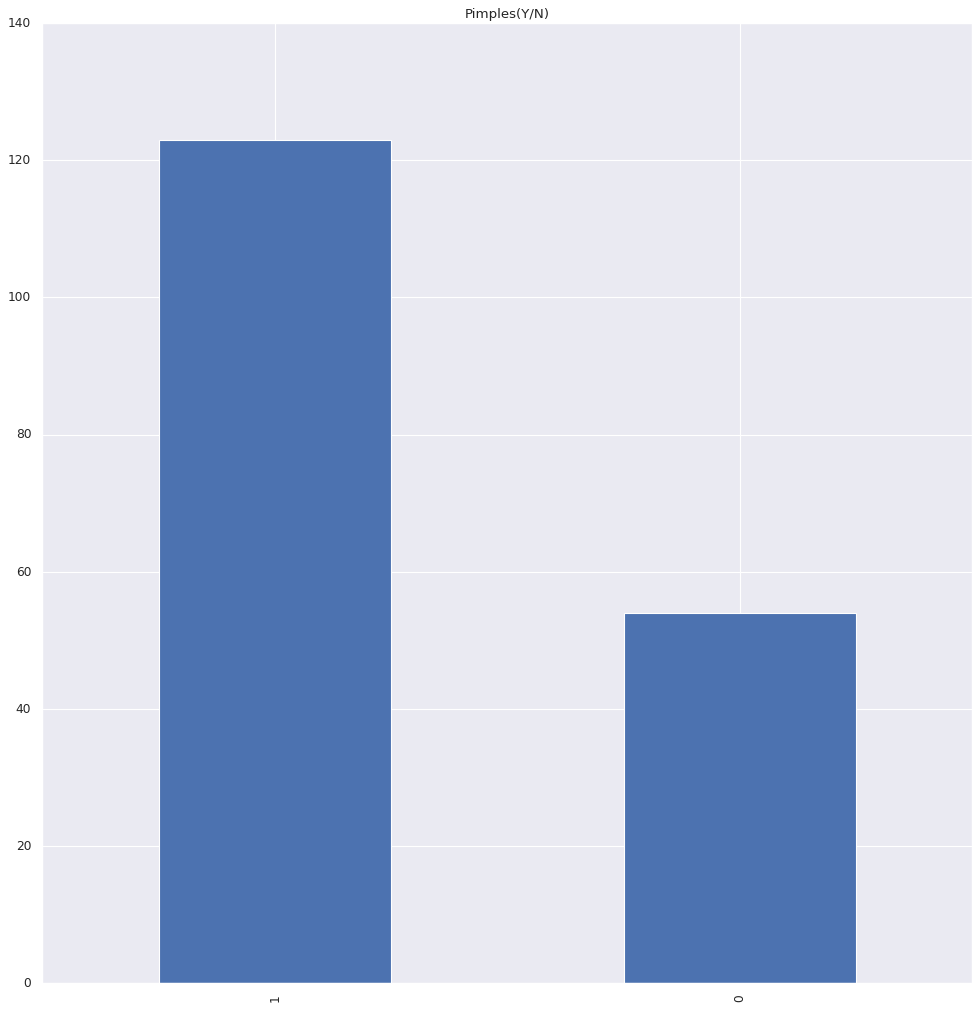

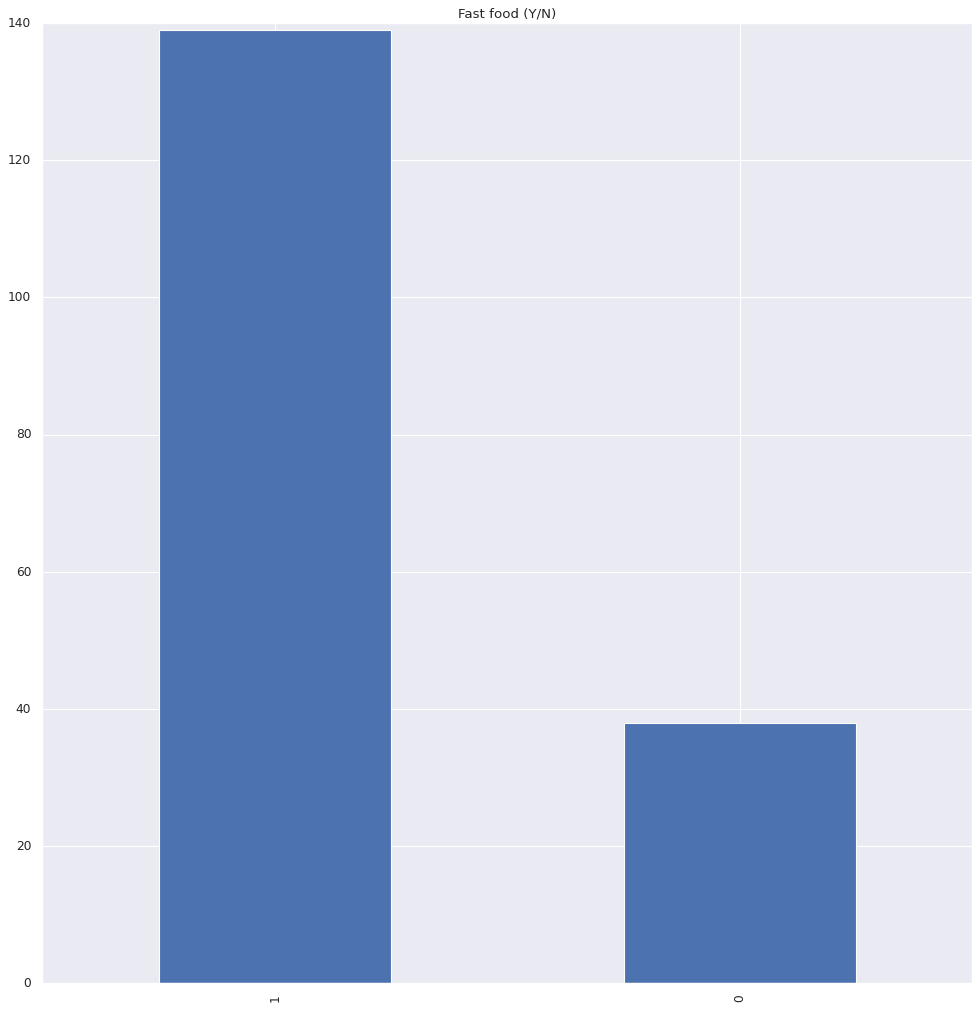

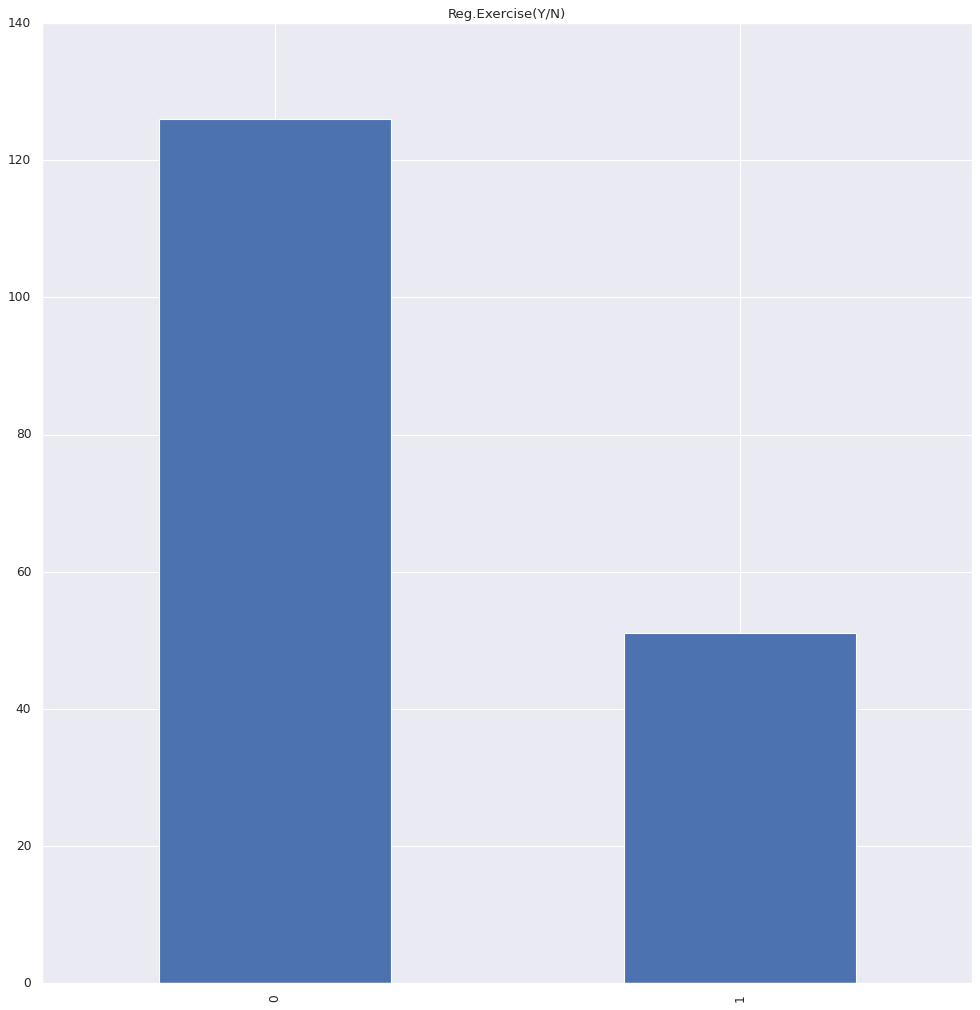

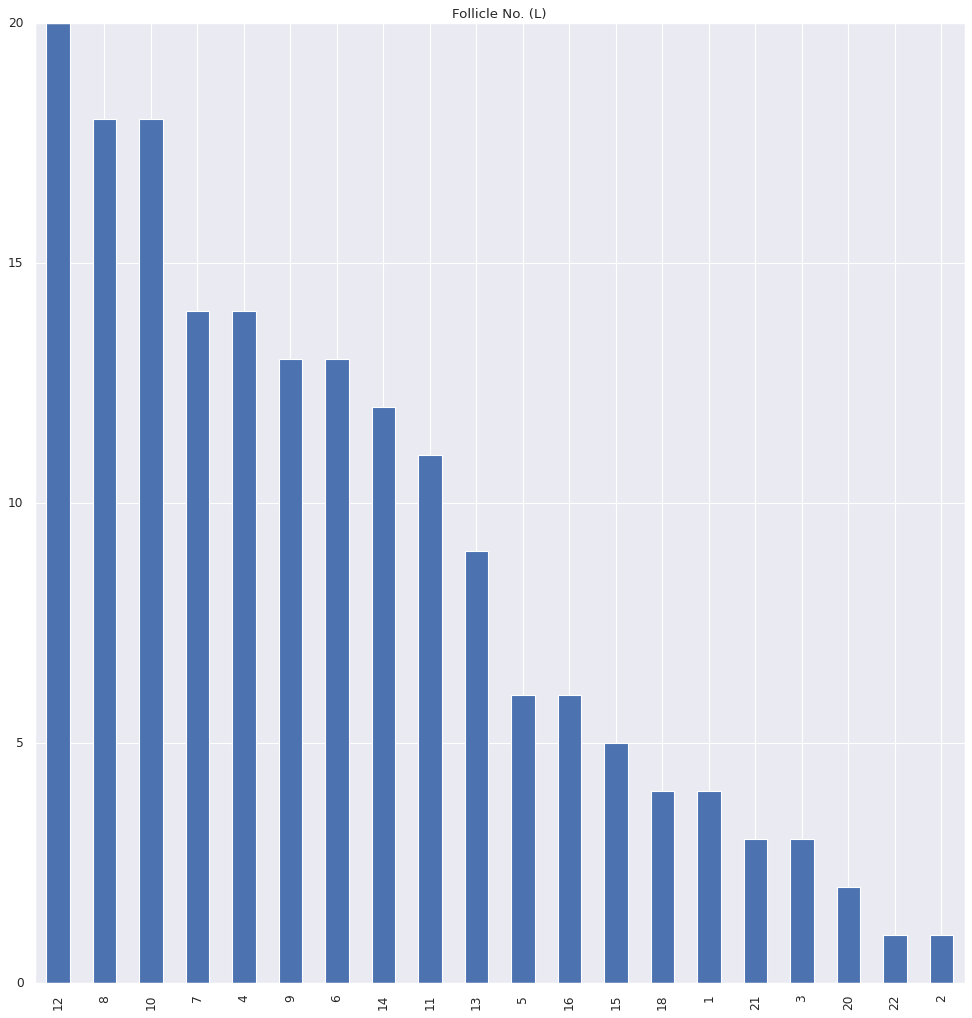

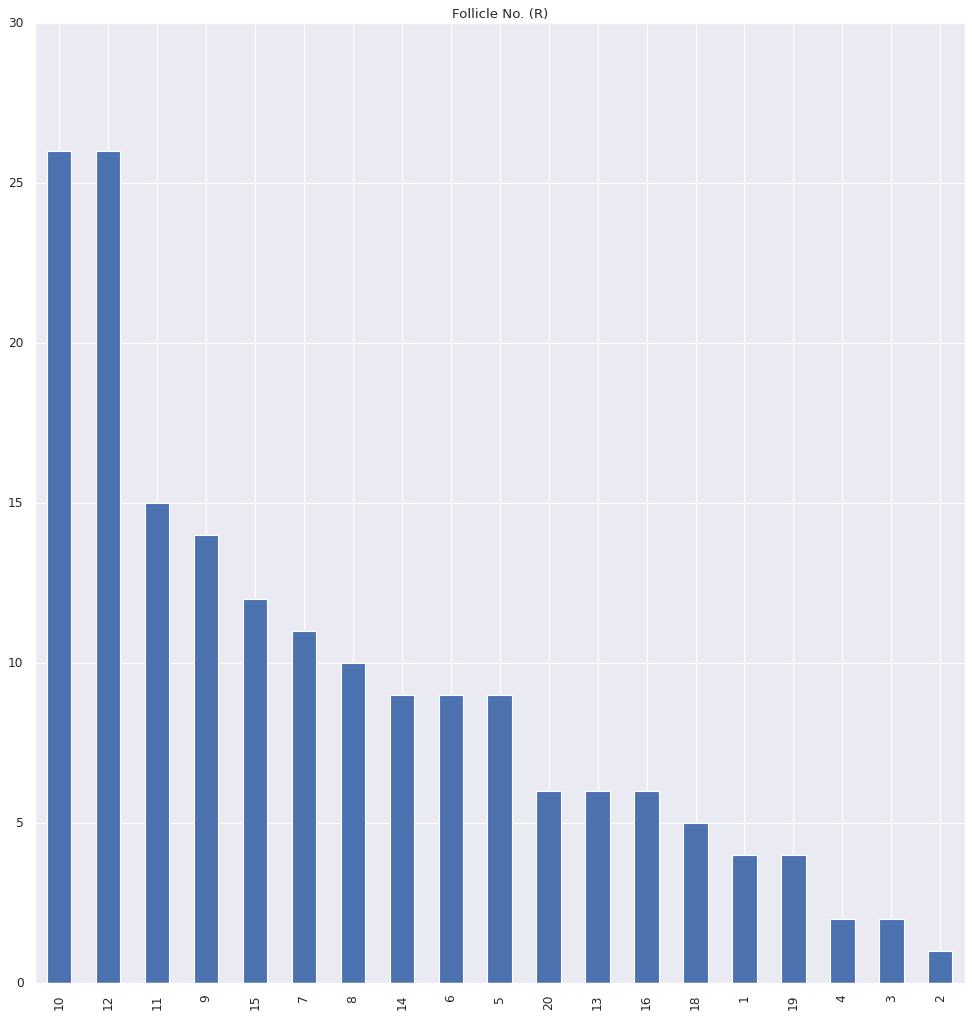

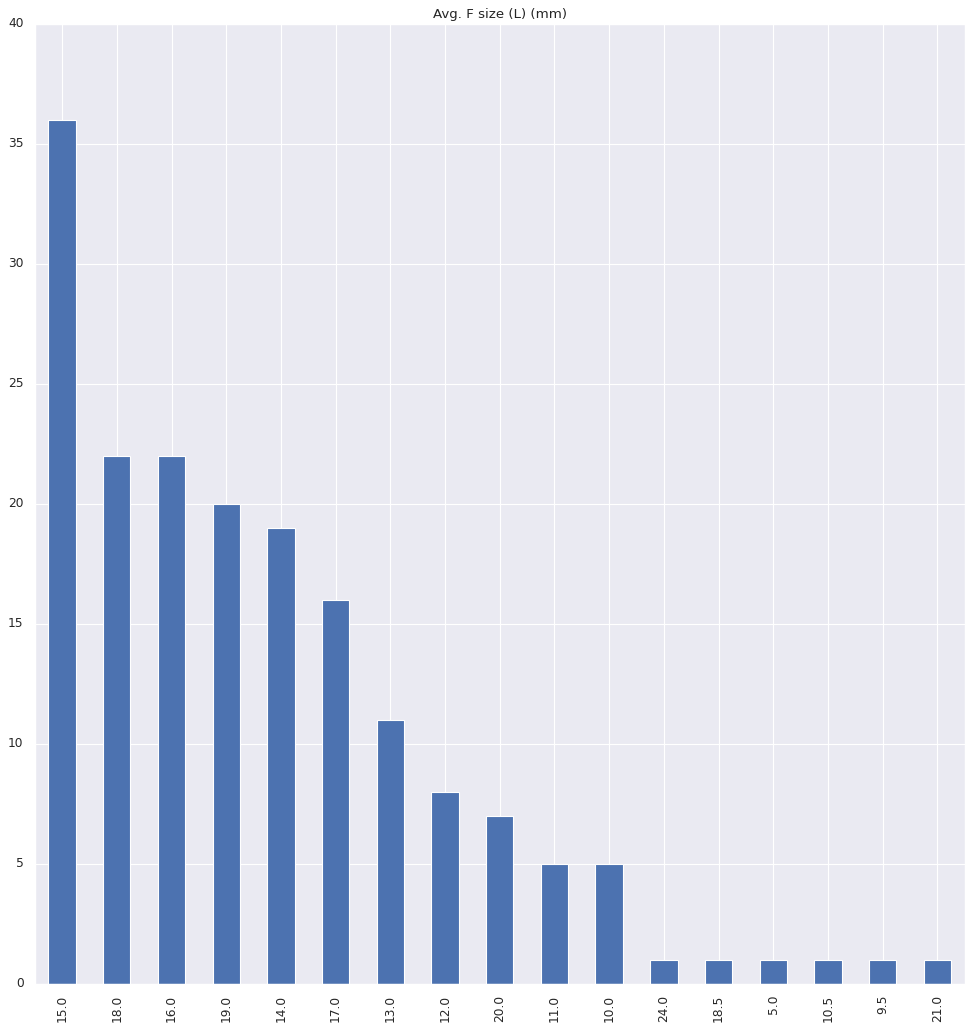

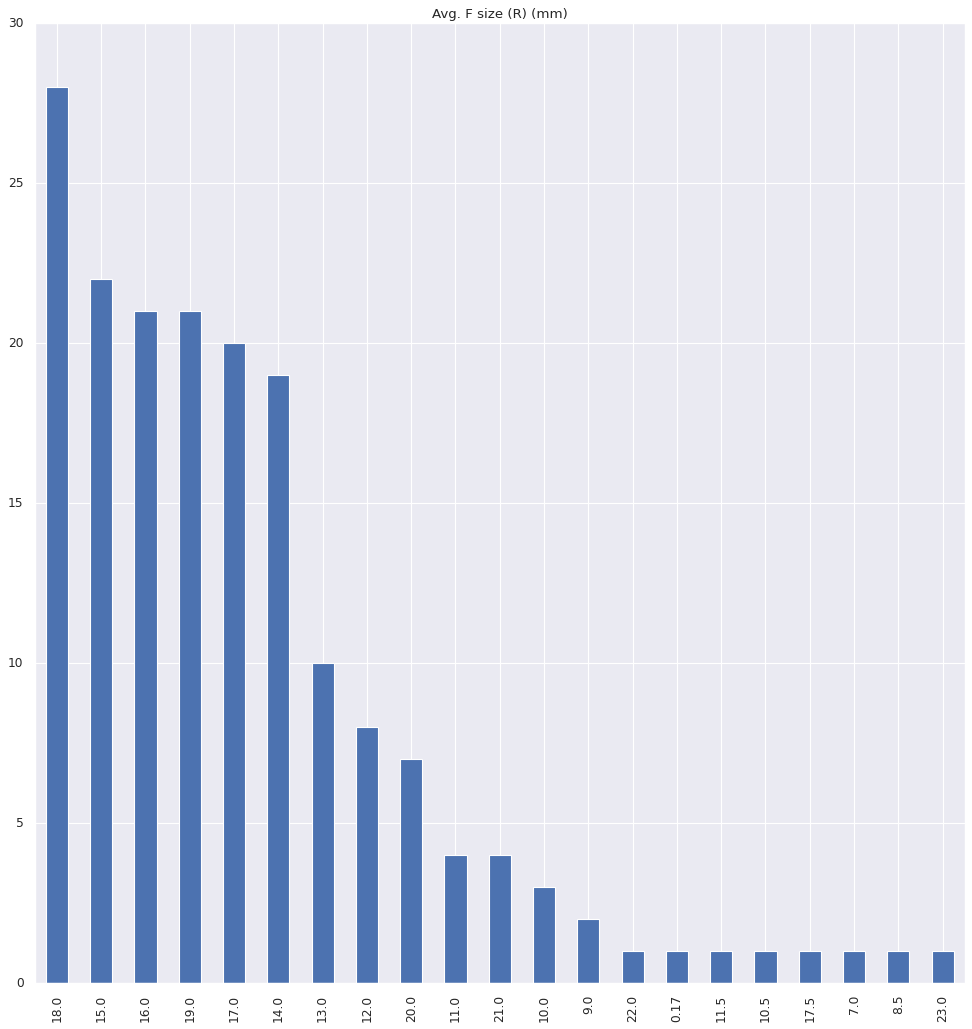

In [ ]:
for i in [' Age (yrs)', 'BMI', 'Blood Group', 'Pulse rate(bpm) ',
       'Hb(g/dl)', 'Cycle length(days)', 'Pregnant(Y/N)', 'No. of abortions',
       'Waist:Hip Ratio', 'TSH (mIU/L)', 'Weight gain(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Follicle No. (L)',
       'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)']:
  sns.set(rc = {'figure.figsize':(15,15)})
  df[df['PCOS (Y/N)'] == 1][i].value_counts().plot.bar()
  plt.title(i)
  plt.show()

In [ ]:
#sns.pairplot(df)
#plt.show()
#plt.close()

In [ ]:
#MACHINE LEARNING MODELS

In [ ]:
#PCOS Detection using Builtin Logistic regression

In [ ]:
X = df_new.drop(['PCOS (Y/N)'],axis=1)
y = df_new['PCOS (Y/N)']

In [ ]:
x_train, x_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N),Pimples(Y/N),AMH(ng/mL),Weight (Kg)
182,1,1,0,1,0,2,0,1,1.35,50.0
244,7,9,1,1,1,2,1,1,4.10,104.0
540,10,9,1,1,1,4,1,1,20.00,82.0
391,2,1,0,0,1,2,0,0,1.20,60.0
454,13,12,1,0,0,2,1,1,9.70,61.0
...,...,...,...,...,...,...,...,...,...,...
71,6,5,0,0,0,2,0,0,2.58,61.0
106,4,6,1,1,1,4,0,1,3.90,60.0
270,6,7,1,1,1,2,1,1,4.10,55.1
436,4,4,0,0,0,2,1,0,3.60,48.0


In [ ]:
logreg = LogisticRegression()

In [ ]:
logreg.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = logreg.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
classification_rep = classification_report(y_test, y_pred)

In [ ]:
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.8888888888888888
Confusion Matrix:
[[71  4]
 [ 8 25]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        75
           1       0.86      0.76      0.81        33

    accuracy                           0.89       108
   macro avg       0.88      0.85      0.86       108
weighted avg       0.89      0.89      0.89       108



In [ ]:
#PCOS Detection using Our Logistic Regression model

In [ ]:
import numpy as np

class Logistic_Regression_scratch:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        # Initialize hyperparameters of the model
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations

    def sigmoid(self, z):
        # Sigmoid function to map the output to a probability value
        return 1 / (1 + np.exp(-z))

    def initialize_weights(self, num_features):
        # Initialize model weights and bias to zeros
        self.weights = np.zeros(num_features)
        self.bias = 0
    def fit(self, X, y):
        # Add a bias column to the input features for the intercept term
        #X = np.insert(X, 0, 1, axis=1)

        # Initialize weights and bias
        self.initialize_weights(X.shape[1])

        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_model)
            error = y - predictions

            # Update weights and bias using gradient descent
            self.weights += self.learning_rate * np.dot(X.T, error) / X.shape[0]
            self.bias += self.learning_rate * np.sum(error) / X.shape[0]

    def predict(self, X):
        # Add a bias column to the input features for the intercept term
        #X = np.insert(X, 0, 1, axis=1)

        # Predicted probabilities using the sigmoid function
        predictions = self.sigmoid(np.dot(X, self.weights) + self.bias)

        # Convert probabilities to binary predictions (0 or 1)
        return np.round(predictions)


In [ ]:
model1 = Logistic_Regression_scratch(learning_rate=0.01,num_iterations=1000)
model1.fit(x_train,y_train)
predictions = model1.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test,predictions)
conf_matrix = confusion_matrix(y_test,predictions)
classification_rep = classification_report(y_test, predictions)
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.7222222222222222
Confusion Matrix:
[[75  0]
 [30  3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        75
           1       1.00      0.09      0.17        33

    accuracy                           0.72       108
   macro avg       0.86      0.55      0.50       108
weighted avg       0.80      0.72      0.63       108

